# Проект: Прогнозная система для отбора молочных коров

## Бизнес-контекст

Молочное хозяйство **«Вольный луг»** планирует расширить поголовье коров, заключив контракт с ассоциацией пастбищ **«ЭкоФерма»**. В рамках соглашения фермер имеет возможность тщательного отбора животных, но существует риск приобретения коров, не соответствующих строгим производственным стандартам.

## Проблема

Для устойчивого развития и выполнения бизнес-плана необходимо, чтобы каждая приобретаемая корова соответствовала **двум ключевым критериям**:

- **Высокая продуктивность**: годовой удой ≥ 6000 кг
- **Качество продукции**: молоко должно классифицироваться как **«вкусное»** по внутренней методике фермера

Текущий процесс отбора подвержен субъективным оценкам и заявлениям продавцов, что приводит к финансовым и операционным рискам.

## Цели проекта

Разработать инструмент на основе машинного обучения для объективной оценки коров при покупке. Система должна включать две прогнозные модели:

### Модель 1: Прогнозирование удоя
- **Тип**: Регрессия
- **Целевая переменная**: `Удой` (кг/год)
- **Задача**: предсказание численного значения годового удоя

### Модель 2: Оценка качества молока
- **Тип**: Классификация
- **Целевая переменная**: `Вкус молока`
- **Задача**: определение вероятности отнесения молока к категории «вкусное»

## Критерии отбора коров

Корова рекомендуется к покупке при одновременном выполнении:
1. Спрогнозированный годовой **удой** ≥ 6000 кг
2. Прогнозируемая вероятность **«вкусного» молока** ≥ 0.5

## Источники данных

Для обучения моделей предоставлен датасет от **«ЭкоФерма»**, содержащий:
- Исторические данные о коровах
- Показатели здоровья и продуктивности
- Породу и генетические параметры
- Условия содержания и кормления
- Результаты лабораторных анализов молока

## Технические требования

- Обе модели должны демонстрировать высокую точность прогноза
- Система должна быть интерпретируемой для фермера
- Решение должно быть масштабируемым для регулярного использования

In [1]:
!pip install scikit-learn --upgrade # РЕВЬЮЕР

     |████████████████████████████████| 13.5 MB 2.0 MB/s eta 0:00:01
     |████████████████████████████████| 308 kB 81.9 MB/s eta 0:00:01
  Attempting uninstall: joblib
    Found existing installation: joblib 1.1.0
    Uninstalling joblib-1.1.0:
      Successfully uninstalled joblib-1.1.0
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 0.24.1
    Uninstalling scikit-learn-0.24.1:
      Successfully uninstalled scikit-learn-0.24.1


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

## Загрузка данных

Загрузим данные в 3 разные таблицы

In [3]:
try:
    df_ferma_main = pd.read_csv('./datasets/ferma_main.csv', sep=';')
    df_ferma_dad = pd.read_csv('./datasets/ferma_dad.csv', sep=';')
    df_cow_buy = pd.read_csv('./datasets/cow_buy.csv', sep=';')
except:
    df_ferma_main = pd.read_csv('https://code.s3.yandex.net/datasets/ferma_main.csv', sep=';')
    df_ferma_dad = pd.read_csv('https://code.s3.yandex.net/datasets/ferma_dad.csv', sep=';')
    df_cow_buy = pd.read_csv('https://code.s3.yandex.net/datasets/cow_buy.csv', sep=';')

Рассмотрим все 3 датасета поближе, начнём с датасета с коровами из фермы

In [4]:
df_ferma_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 12 columns):
 #   Column                                 Non-Null Count  Dtype 
---  ------                                 --------------  ----- 
 0   id                                     634 non-null    int64 
 1   Удой, кг                               634 non-null    int64 
 2   ЭКЕ (Энергетическая кормовая единица)  634 non-null    object
 3   Сырой протеин, г                       634 non-null    int64 
 4   СПО (Сахаро-протеиновое соотношение)   634 non-null    object
 5   Порода                                 634 non-null    object
 6   Тип пастбища                           634 non-null    object
 7   порода папы_быка                       634 non-null    object
 8   Жирность,%                             634 non-null    object
 9   Белок,%                                634 non-null    object
 10  Вкус молока                            634 non-null    object
 11  Возраст            

Пропусков не замечено, типы данных и названия столбцов придётся поправить

In [5]:
df_ferma_main.head()

,id,"Удой, кг",ЭКЕ (Энергетическая кормовая единица),"Сырой протеин, г",СПО (Сахаро-протеиновое соотношение),Порода,Тип пастбища,порода папы_быка,"Жирность,%","Белок,%",Вкус молока,Возраст
0,1,5863,"14,2",1743,"0,89",Вис Бик Айдиал,Равнинное,Айдиал,"3,58","3,076",вкусно,более_2_лет
1,2,5529,"12,8",2138,"0,89",Вис Бик Айдиал,Равнинные,Соверин,"3,54","3,079",вкусно,менее_2_лет
2,3,5810,14,1854,"0,885",РефлешнСоверинг,Холмистое,Соверин,"3,59","3,074",не вкусно,более_2_лет
3,4,5895,"12,4",2012,"0,885",РефлешнСоверинг,Холмистое,Айдиал,"3,4","3,075",не вкусно,более_2_лет
4,5,5302,"12,8",1675,"0,885",Вис Бик Айдиал,Равнинные,Соверин,"3,73","3,073",вкусно,менее_2_лет


Переименуем столбцы

In [6]:
df_ferma_main.columns = ['id', 'milk_yield', 'eke', 'raw_protein', 'spo', 'kind', 'pasture_kind', 'father_kind', 'fat_percent', 'protein_percent', 'milk_taste', 'age']

Проверим, переименовались ли они

In [7]:
df_ferma_main.columns

Index(['id', 'milk_yield', 'eke', 'raw_protein', 'spo', 'kind', 'pasture_kind',
       'father_kind', 'fat_percent', 'protein_percent', 'milk_taste', 'age'],
      dtype='object')

Рассмотрим датасет с информацией о папах коров

In [8]:
df_ferma_dad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        629 non-null    int64 
 1   Имя Папы  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB


Количество записей в таблице с папами не соответствует количеству коров в датасете. Возможно датасет с папами неполон, либо в датасете с коровами есть дупликаты. Названия столбцов нужно поменять

In [9]:
df_ferma_dad.head()

,id,Имя Папы
0,1,Буйный
1,2,Соловчик
2,3,Барин
3,4,Буйный
4,5,Барин


In [10]:
df_ferma_dad.columns = ['id', 'father_name']

Проверим, применились ли изменения

In [11]:
df_ferma_dad.columns

Index(['id', 'father_name'], dtype='object')

Рассмотрим датасет с коровами из "ЭкоФермы"

In [12]:
df_cow_buy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Порода                   20 non-null     object
 1   Тип пастбища             20 non-null     object
 2   порода папы_быка         20 non-null     object
 3   Имя_папы                 20 non-null     object
 4   Текущая_жирность,%       20 non-null     object
 5   Текущий_уровень_белок,%  20 non-null     object
 6   Возраст                  20 non-null     object
dtypes: object(7)
memory usage: 1.2+ KB


Имена и типы придётся изменить

In [13]:
df_cow_buy.head()

,Порода,Тип пастбища,порода папы_быка,Имя_папы,"Текущая_жирность,%","Текущий_уровень_белок,%",Возраст
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,"3,54","3,081",менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,"3,4","3,061",более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,"3,64","3,074",более_2_лет


Переименуем столбцы, проверим применились ли изменения

In [14]:
df_cow_buy.columns = ['kind', 'pasture_kind', 'father_kind', 'father_name', 'fat_percent', 'protein_percent', 'age']

In [15]:
df_cow_buy.columns

Index(['kind', 'pasture_kind', 'father_kind', 'father_name', 'fat_percent',
       'protein_percent', 'age'],
      dtype='object')

#### Вывод
В результате выполнения этапа загружены 3 датасета. У датасетов были выявлены следующие проблемы:
 - Имена столбцов не подходят для дальнейшей работы. Изменения были внесены
 - Количество записей в датасете с папами коров не соответствует количеству записей в датасете с коровами. Изъян будет устранён в разделе "Предобработка данных"
 - Типы данных в датасетах с коровами нашей фермы и "ЭкоФермы" не подходят для работы. Будет исправлено в разделе "Предобработка данных"

##  Предобработка данных

Обработаем датасет с коровами фермы. Начнём с дупликатов

In [16]:
df_ferma_main.duplicated().sum()

5

Выявлено 5 дупликатов, уберём их, проверим применились ли изменения

In [17]:
df_ferma_main.drop_duplicates(inplace=True)
df_ferma_main.duplicated().sum()

0

Проверим категориальные признаки на наличие неявных дупликатов, в случае обнаружения - исправим

In [18]:
df_ferma_main['kind'].unique()

array(['Вис Бик Айдиал', 'РефлешнСоверинг'], dtype=object)

In [19]:
df_ferma_main['pasture_kind'].unique()

array(['Равнинное', 'Равнинные', 'Холмистое'], dtype=object)

In [20]:
df_ferma_main.loc[df_ferma_main['pasture_kind'] == 'Равнинные', 'pasture_kind'] = 'Равнинное'
df_ferma_main['pasture_kind'].unique()

array(['Равнинное', 'Холмистое'], dtype=object)

In [21]:
df_ferma_main.duplicated().sum()

0

Проверим столбец с именами пап на неявные дубли

In [22]:
df_ferma_main['father_kind'].unique()

array(['Айдиал', 'Соверин', 'Айдиалл'], dtype=object)

Уберём неявные дубли

In [23]:
df_ferma_main.loc[df_ferma_main['father_kind'] == 'Айдиалл', 'father_kind'] = 'Айдиал'
df_ferma_main['father_kind'].unique()

array(['Айдиал', 'Соверин'], dtype=object)

Проверим явные дубли

In [24]:
df_ferma_dad.duplicated().sum()

0

In [25]:
df_ferma_dad['father_name'].unique()

array(['Буйный', 'Соловчик', 'Барин', 'Геркулес'], dtype=object)

Произведём предобработку таблицы с коровами "ЭкоФермы". Начнём с дубликатов

In [26]:
df_cow_buy.duplicated().sum()

4

In [27]:
df_cow_buy.drop_duplicates(inplace=True)
df_cow_buy.duplicated().sum()

0

Проверим неявные дубликаты

In [28]:
df_cow_buy['pasture_kind'].unique()

array(['холмистое', 'равнинное'], dtype=object)

In [29]:
df_cow_buy['father_name'].unique()

array(['Геркулес', 'Буйный', 'Барин', 'Соловчик'], dtype=object)

In [30]:
df_cow_buy['father_kind'].unique()

array(['Айдиал', 'Соверин'], dtype=object)

In [31]:
df_cow_buy['kind'].unique()

array(['Вис Бик Айдиал', 'РефлешнСоверинг'], dtype=object)

In [32]:
df_cow_buy['age'].unique()

array(['более_2_лет', 'менее_2_лет'], dtype=object)

Проверим все 3 таблицы на наличие пропусков

In [33]:
df_ferma_main.isna().sum()

id                 0
milk_yield         0
eke                0
raw_protein        0
spo                0
kind               0
pasture_kind       0
father_kind        0
fat_percent        0
protein_percent    0
milk_taste         0
age                0
dtype: int64

In [34]:
df_ferma_dad.isna().sum()

id             0
father_name    0
dtype: int64

In [35]:
df_cow_buy.isna().sum()

kind               0
pasture_kind       0
father_kind        0
father_name        0
fat_percent        0
protein_percent    0
age                0
dtype: int64

Поменяем типы, там где это необходимо. Для начала повторно выведем данные

In [36]:
df_ferma_main.head()

,id,milk_yield,eke,raw_protein,spo,kind,pasture_kind,father_kind,fat_percent,protein_percent,milk_taste,age
0,1,5863,"14,2",1743,"0,89",Вис Бик Айдиал,Равнинное,Айдиал,"3,58","3,076",вкусно,более_2_лет
1,2,5529,"12,8",2138,"0,89",Вис Бик Айдиал,Равнинное,Соверин,"3,54","3,079",вкусно,менее_2_лет
2,3,5810,14,1854,"0,885",РефлешнСоверинг,Холмистое,Соверин,"3,59","3,074",не вкусно,более_2_лет
3,4,5895,"12,4",2012,"0,885",РефлешнСоверинг,Холмистое,Айдиал,"3,4","3,075",не вкусно,более_2_лет
4,5,5302,"12,8",1675,"0,885",Вис Бик Айдиал,Равнинное,Соверин,"3,73","3,073",вкусно,менее_2_лет


In [37]:
df_ferma_main.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 629 entries, 0 to 628
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               629 non-null    int64 
 1   milk_yield       629 non-null    int64 
 2   eke              629 non-null    object
 3   raw_protein      629 non-null    int64 
 4   spo              629 non-null    object
 5   kind             629 non-null    object
 6   pasture_kind     629 non-null    object
 7   father_kind      629 non-null    object
 8   fat_percent      629 non-null    object
 9   protein_percent  629 non-null    object
 10  milk_taste       629 non-null    object
 11  age              629 non-null    object
dtypes: int64(3), object(9)
memory usage: 63.9+ KB


Столбцы с ЭКЕ, СПО, жирностью и содержанием белка типа `object`, хотя они числовые. Исправим, проверим изменения

In [38]:
def to_numeric(df, column_name):
    df[column_name] = pd.to_numeric(df[column_name].str.replace(',', '.'))

problem_columns = ['eke', 'spo', 'fat_percent', 'protein_percent']
for col in problem_columns:
    to_numeric(df_ferma_main, col)

In [39]:
df_ferma_main.head()

,id,milk_yield,eke,raw_protein,spo,kind,pasture_kind,father_kind,fat_percent,protein_percent,milk_taste,age
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,Равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,Равнинное,Соверин,3.54,3.079,вкусно,менее_2_лет
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,Холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,Холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет
4,5,5302,12.8,1675,0.885,Вис Бик Айдиал,Равнинное,Соверин,3.73,3.073,вкусно,менее_2_лет


In [40]:
df_ferma_main.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 629 entries, 0 to 628
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               629 non-null    int64  
 1   milk_yield       629 non-null    int64  
 2   eke              629 non-null    float64
 3   raw_protein      629 non-null    int64  
 4   spo              629 non-null    float64
 5   kind             629 non-null    object 
 6   pasture_kind     629 non-null    object 
 7   father_kind      629 non-null    object 
 8   fat_percent      629 non-null    float64
 9   protein_percent  629 non-null    float64
 10  milk_taste       629 non-null    object 
 11  age              629 non-null    object 
dtypes: float64(4), int64(3), object(5)
memory usage: 63.9+ KB


Посмотрим на типы у датасета с папами

In [41]:
df_ferma_dad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 629 entries, 0 to 628
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           629 non-null    int64 
 1   father_name  629 non-null    object
dtypes: int64(1), object(1)
memory usage: 10.0+ KB


Типы подходят

Типы у столбцов с коровами "ЭкоФермы" должны совпадать с соответствующими типами столбцов из таблицы с коровами заказчика

In [42]:
df_cow_buy.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16 entries, 0 to 18
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   kind             16 non-null     object
 1   pasture_kind     16 non-null     object
 2   father_kind      16 non-null     object
 3   father_name      16 non-null     object
 4   fat_percent      16 non-null     object
 5   protein_percent  16 non-null     object
 6   age              16 non-null     object
dtypes: object(7)
memory usage: 1.0+ KB


In [43]:
df_cow_buy.head()

,kind,pasture_kind,father_kind,father_name,fat_percent,protein_percent,age
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,"3,58","3,076",более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,"3,54","3,081",менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,"3,59","3,074",более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,"3,4","3,061",более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,"3,64","3,074",более_2_лет


Типы не совпадают - исправим

In [44]:
problem_columns = ['fat_percent', 'protein_percent']
for col in problem_columns:
    to_numeric(df_cow_buy, col)

In [45]:
df_cow_buy.head()

,kind,pasture_kind,father_kind,father_name,fat_percent,protein_percent,age
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет


#### Вывод
Произведена предобработка данных 2 датасетах. Были выявлены проблемные столбцы, ошибки исправлены. Список проблемных столбцов:
 - Жирность молока
 - Содержание белка в молоке
 - ЭКЕ
 - СПО

## Исследовательский анализ данных

Проведём статистический анализ всех признаков. Используем боксплоты и гистограммы для количественных признаков, круговые диаграммы для категориальных признаков

Выведем статистики для всех столбцов датасета с коровами заказчика

In [46]:
df_ferma_main.describe()

,id,milk_yield,eke,raw_protein,spo,fat_percent,protein_percent
count,629.00000,629.000000,629.000000,629.000000,629.000000,629.000000,629.000000
mean,315.00000,6188.750397,14.543879,1923.364070,0.913116,3.603657,3.075671
std,181.72094,1644.795489,1.306408,182.956251,0.032203,0.168656,0.002549
min,1.00000,5204.000000,10.900000,1660.000000,0.840000,2.990000,3.069000
25%,158.00000,5751.000000,13.500000,1771.000000,0.890000,3.590000,3.074000
50%,315.00000,6133.000000,14.700000,1888.000000,0.930000,3.650000,3.076000
75%,472.00000,6501.000000,15.600000,2062.000000,0.940000,3.720000,3.077000
max,629.00000,45616.000000,16.800000,2349.000000,0.960000,3.750000,3.085000


<AxesSubplot:xlabel='milk_yield'>

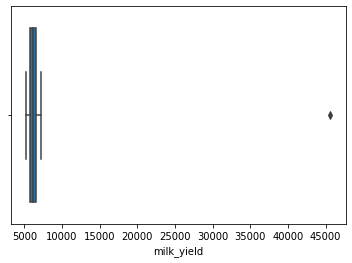

In [47]:
sns.boxplot(data=df_ferma_main, x='milk_yield')

Корова с удоем >45000 - выброс, его стоит убрать. После этого проверим статистики датасета на изменения

In [48]:
df_ferma_main = df_ferma_main.query('milk_yield < 10000 and milk_yield > 4600')
df_ferma_main.describe()

,id,milk_yield,eke,raw_protein,spo,fat_percent,protein_percent
count,628.000000,628.000000,628.000000,628.000000,628.000000,628.000000,628.000000
mean,315.474522,6125.968153,14.548726,1923.759554,0.913089,3.604268,3.075670
std,181.475367,475.857053,1.301777,182.832816,0.032221,0.168093,0.002551
min,1.000000,5204.000000,10.900000,1660.000000,0.840000,2.990000,3.069000
25%,158.750000,5749.750000,13.500000,1771.750000,0.890000,3.590000,3.074000
50%,315.500000,6132.500000,14.700000,1888.000000,0.930000,3.650000,3.076000
75%,472.250000,6501.000000,15.600000,2062.250000,0.940000,3.720000,3.077000
max,629.000000,7222.000000,16.800000,2349.000000,0.960000,3.750000,3.085000


Text(0.5, 0, '')

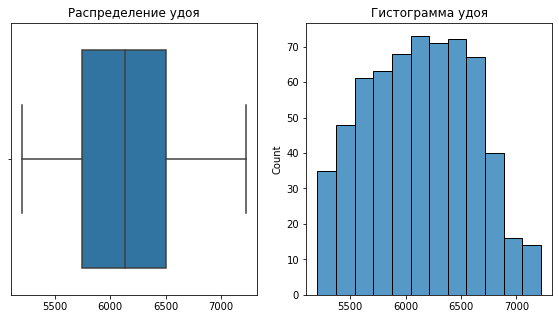

In [49]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(data=df_ferma_main, x='milk_yield')
plt.title('Распределение удоя')
plt.xlabel('')
plt.subplot(1, 3, 2)
sns.histplot(data=df_ferma_main, x='milk_yield')
plt.title('Гистограмма удоя')
plt.xlabel('')

В среднем коровы на ферме заказчика дают ~6200 литров молока в год. Распределение близко к нормальному, однако виден хвост у высокопроизводительных коров. В наборе данных есть объекты с высоким и низким показателем таргетного признака, это хорошо скажется на обучении модели в будущем

Text(0.5, 0, '')

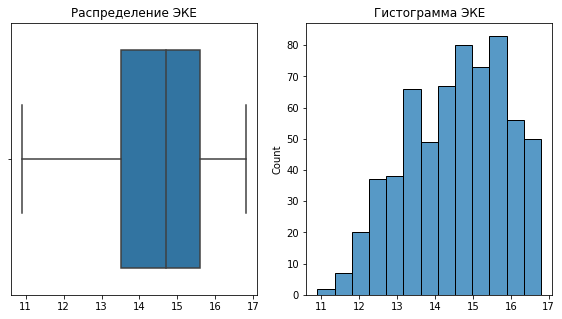

In [50]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(data=df_ferma_main, x='eke')
plt.title('Распределение ЭКЕ')
plt.xlabel('')
plt.subplot(1, 3, 2)
sns.histplot(data=df_ferma_main, x='eke')
plt.title('Гистограмма ЭКЕ')
plt.xlabel('')

ЭКЕ обладает необычным распределением. Присутствуют коровы которых кормят значительно меньше чем большинство

Text(0.5, 0, '')

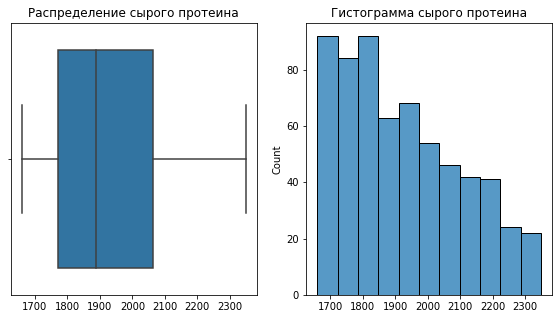

In [51]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(data=df_ferma_main, x='raw_protein')
plt.title('Распределение сырого протеина')
plt.xlabel('')
plt.subplot(1, 3, 2)
sns.histplot(data=df_ferma_main, x='raw_protein')
plt.title('Гистограмма сырого протеина')
plt.xlabel('')

Распределение также необычное. Некоторым коровам нужно большее содержание белка в корме

Text(0.5, 0, '')

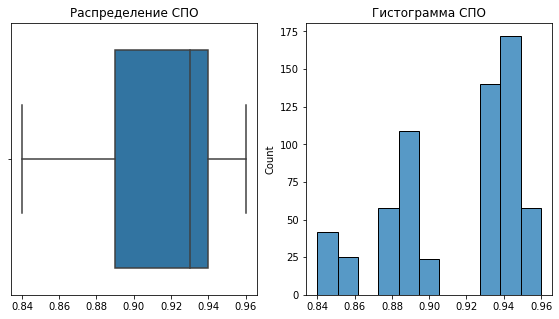

In [52]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(data=df_ferma_main, x='spo')
plt.title('Распределение СПО')
plt.xlabel('')
plt.subplot(1, 3, 2)
sns.histplot(data=df_ferma_main, x='spo')
plt.title('Гистограмма СПО')
plt.xlabel('')

СПО хоть и является числовым признаком, но хорошо дискретизирован. В будущем стоит сделать из него категориальный признак

Text(0.5, 0, '')

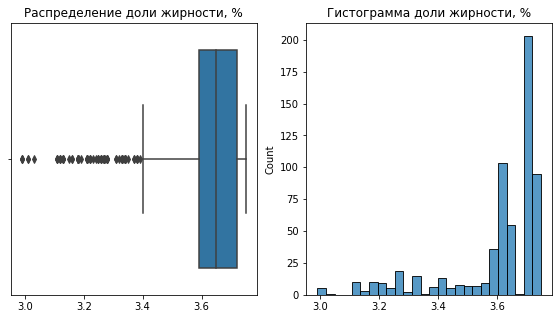

In [53]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(data=df_ferma_main, x='fat_percent')
plt.title('Распределение доли жирности, %')
plt.xlabel('')
plt.subplot(1, 3, 2)
sns.histplot(data=df_ferma_main, x='fat_percent')
plt.title('Гистограмма доли жирности, %')
plt.xlabel('')

У жирности молока наблюдается много выбросов. Распределение также необычное. Хоть данные и являются выбросами, на аномальные они не похожи, оставляем

Text(0.5, 0, '')

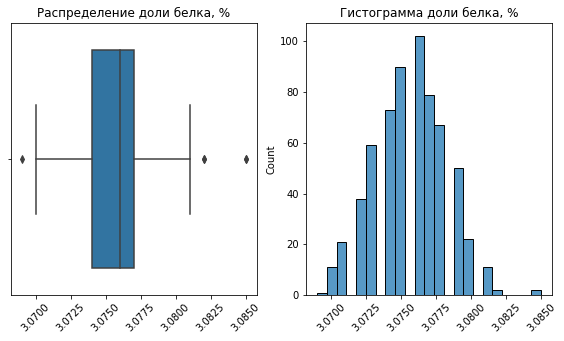

In [54]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(data=df_ferma_main, x='protein_percent')
plt.title('Распределение доли белка, %')
plt.xticks(rotation=45)
plt.xlabel('')
plt.subplot(1, 3, 2)
sns.histplot(data=df_ferma_main, x='protein_percent')
plt.title('Гистограмма доли белка, %')
plt.xticks(rotation=45)
plt.xlabel('')

Доля белка в молоке также имеет выбросы не похожие на аномальные, распределение близко к нормальному. Оставляем всё как есть

Text(0, 0.5, '')

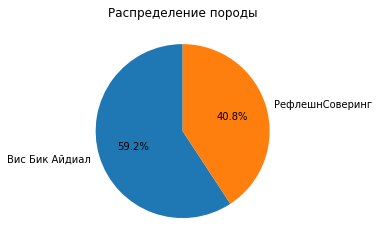

In [55]:
df_ferma_main['kind'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Распределение породы')
plt.ylabel('')

59.2% коров имеют породу Вис Бик Айдиал, 40.8% коров являются Рефлешн Соверингами

Text(0, 0.5, '')

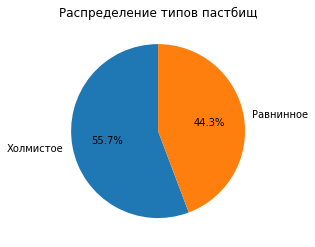

In [56]:
df_ferma_main['pasture_kind'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Распределение типов пастбищ')
plt.ylabel('')

Большинство коров пасётся на холмистых пастбищах

Text(0, 0.5, '')

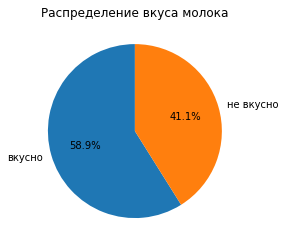

In [57]:
df_ferma_main['milk_taste'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Распределение вкуса молока')
plt.ylabel('')

Больше половины коров дают вкусное молоко, однако 41.1% коров дают невкусное молоко. Число довольно большое

Text(0, 0.5, '')

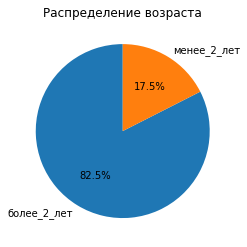

In [58]:
df_ferma_main['age'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Распределение возраста')
plt.ylabel('')

Большинству коров больше двух лет, однако 17.5% коров на ферме - молодые

Text(0, 0.5, '')

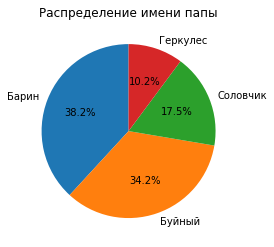

In [59]:
df_ferma_dad['father_name'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Распределение имени папы')
plt.ylabel('')

На верхней диаграмме видно распределение имён пап коров. Больше всего коров произошли от Барина и Буйного

Рассмотрим признаки коров у "ЭкоФермы". Начнём с количественных признаков

In [60]:
df_cow_buy.describe()

,fat_percent,protein_percent
count,16.000000,16.000000
mean,3.571875,3.068250
std,0.141620,0.011264
min,3.340000,3.046000
25%,3.415000,3.059500
50%,3.585000,3.073500
75%,3.692500,3.076750
max,3.770000,3.081000


Text(0.5, 0, '')

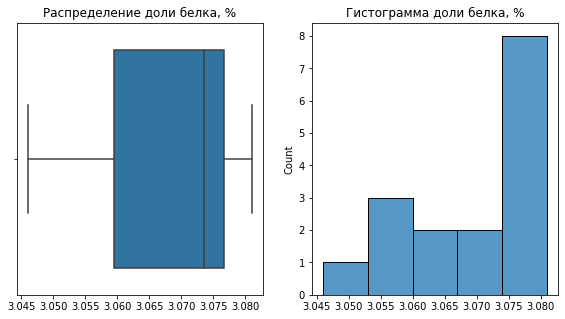

In [61]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(data=df_cow_buy, x='protein_percent')
plt.title('Распределение доли белка, %')
plt.xlabel('')
plt.subplot(1, 3, 2)
sns.histplot(data=df_cow_buy, x='protein_percent')
plt.title('Гистограмма доли белка, %')
plt.xlabel('')

В среднем содержание белка в молоке меньше чем у коров заказчика

Text(0.5, 0, '')

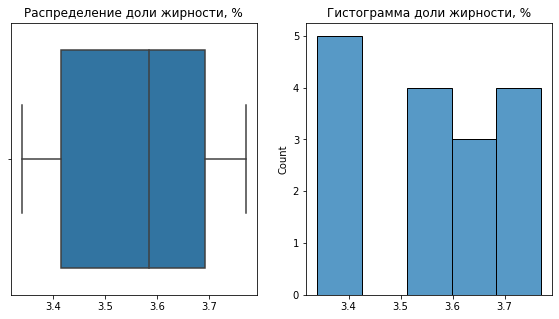

In [62]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.boxplot(data=df_cow_buy, x='fat_percent')
plt.title('Распределение доли жирности, %')
plt.xlabel('')
plt.subplot(1, 3, 2)
sns.histplot(data=df_cow_buy, x='fat_percent')
plt.title('Гистограмма доли жирности, %')
plt.xlabel('')

Молоко у коров "ЭкоФермы" менее жирное чем у заказчика

Text(0, 0.5, '')

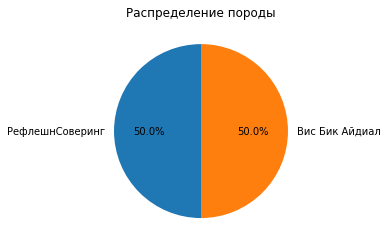

In [63]:
df_cow_buy['kind'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Распределение породы')
plt.ylabel('')

Породы коров "ЭкоФермы" одинаково представлены

Text(0, 0.5, '')

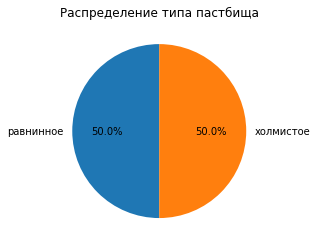

In [64]:
df_cow_buy['pasture_kind'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Распределение типа пастбища')
plt.ylabel('')

С патбищами такая же картина, половина коров "ЭкоФермы" пасутся на равнинных, половина на холмистых

Text(0, 0.5, '')

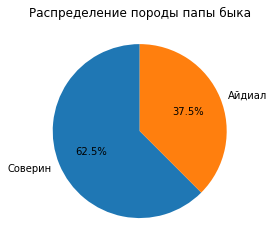

In [65]:
df_cow_buy['father_kind'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Распределение породы папы быка')
plt.ylabel('')

Большинство коров "ЭкоФермы" произошли от папы с породой "Соверин", меньшинство от "Айдиала"

Text(0, 0.5, '')

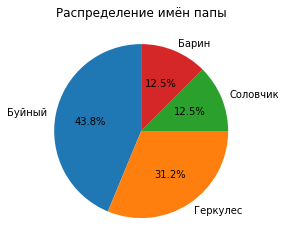

In [66]:
df_cow_buy['father_name'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Распределение имён папы')
plt.ylabel('')

Распределение имён пап коров "ЭкоФермы" также отличается от данных, представленных на ферме заказчика. Потомков коровы с именем "Геркулес" больше, а коров - потомков "Барина" меньше всего

Text(0, 0.5, '')

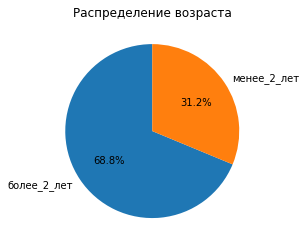

In [67]:
df_cow_buy['age'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Распределение возраста')
plt.ylabel('')

Молодых коров на "ЭкоФерме" больше чем у заказчика

#### Вывод
В результате исследовательского анализа данных были рассмотрены все признаки.
В датасете коров заказчика были замечены следующие особенности:
 - У признака "Удой" был замечен и устранён 1 выброс
 - У признака "СПО" замечено необычное распределение для количественного признака. Признак сильно дискретизирован. В последующем его стоит сделать категориальным
 - Замечены выбросы у признаков доли белка и жирности в молоке. Они не похожи на аномалии, поэтому оставлены без изменений

В датасете заказчика получены следующие инсайты:
 - Доля белка и жирность молока ниже чем у коров заказчика
 - Имена пап коров распределены иначе чем у коров заказчика
 - Доля молодых коров у "Экофермы" больше чем доля молодых коров у заказчика

## Корреляционный анализ

Произведём корреляционный анализ признаков датасета коров заказчика, который будет использован для обучения модели

Для начала построим матрицу корреляции признаков. Перед этим необходимо преобразовать значение категориальных признаков в коды

In [68]:
def preprocess_data(df):
    df_processed = df.copy()
    
    for column in df_processed.columns:
        if df_processed[column].dtype == 'object':
            # Преобразуем строки в категориальные коды
            df_processed[column] = pd.Categorical(df_processed[column]).codes
    
    return df_processed

# Применяем преобразование
data_processed = preprocess_data(df_ferma_main)
data_processed.drop('id', axis=1, inplace=True)

<AxesSubplot:>

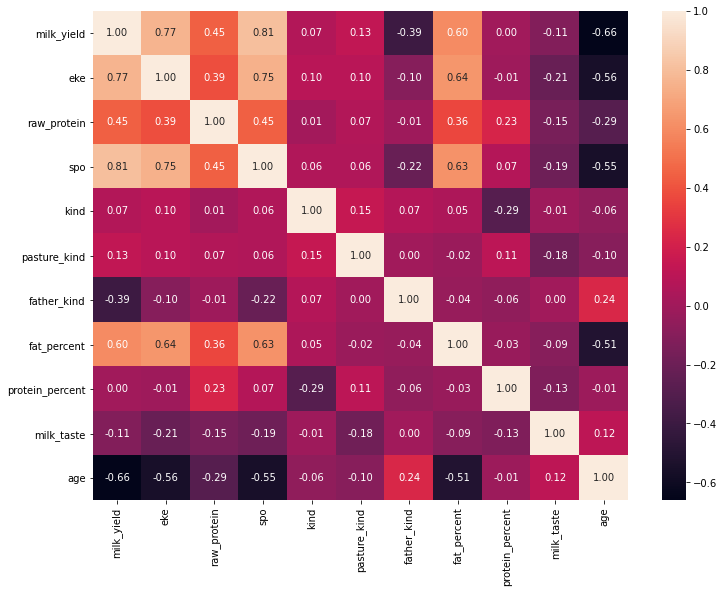

In [69]:
plt.figure(figsize=(12, 9))
sns.heatmap(data_processed.corr(), annot=True, fmt='.2f') 

Мультиколлинеарность замечена между признаками
 - Жирность и ЭКЕ
 - Жирность и доля белка
 - Жирность и СПО
 - Возраст и порода папы
 - СПО и сырой протеин
 - Сырой протеин и ЭКЕ

Построим диаграммы рассеивания для признака "Удой" и всех количественных признаков с учётом значения категориальных признаков

In [70]:
def print_scatters(df, x, y):
    hues = list(df.select_dtypes(include=['object']).columns)
    
    # Создаем фигуру с одним столбцом
    fig, axes = plt.subplots(len(hues), 1, figsize=(16, 10 * len(hues)))
    
    # Если только один график, axes будет не массивом, а одним объектом
    if len(hues) == 1:
        axes = [axes]  # Преобразуем в список для единообразия
    
    for i, hue_col in enumerate(hues):
        sns.scatterplot(data=df, x=x, y=y, hue=hue_col, palette='deep', s=130, ax=axes[i])
        axes[i].set_title(f'{x} vs {y} по {hue_col}')
        axes[i].set_xlabel(x)
        axes[i].set_ylabel(y)
        axes[i].legend(title=hue_col)
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

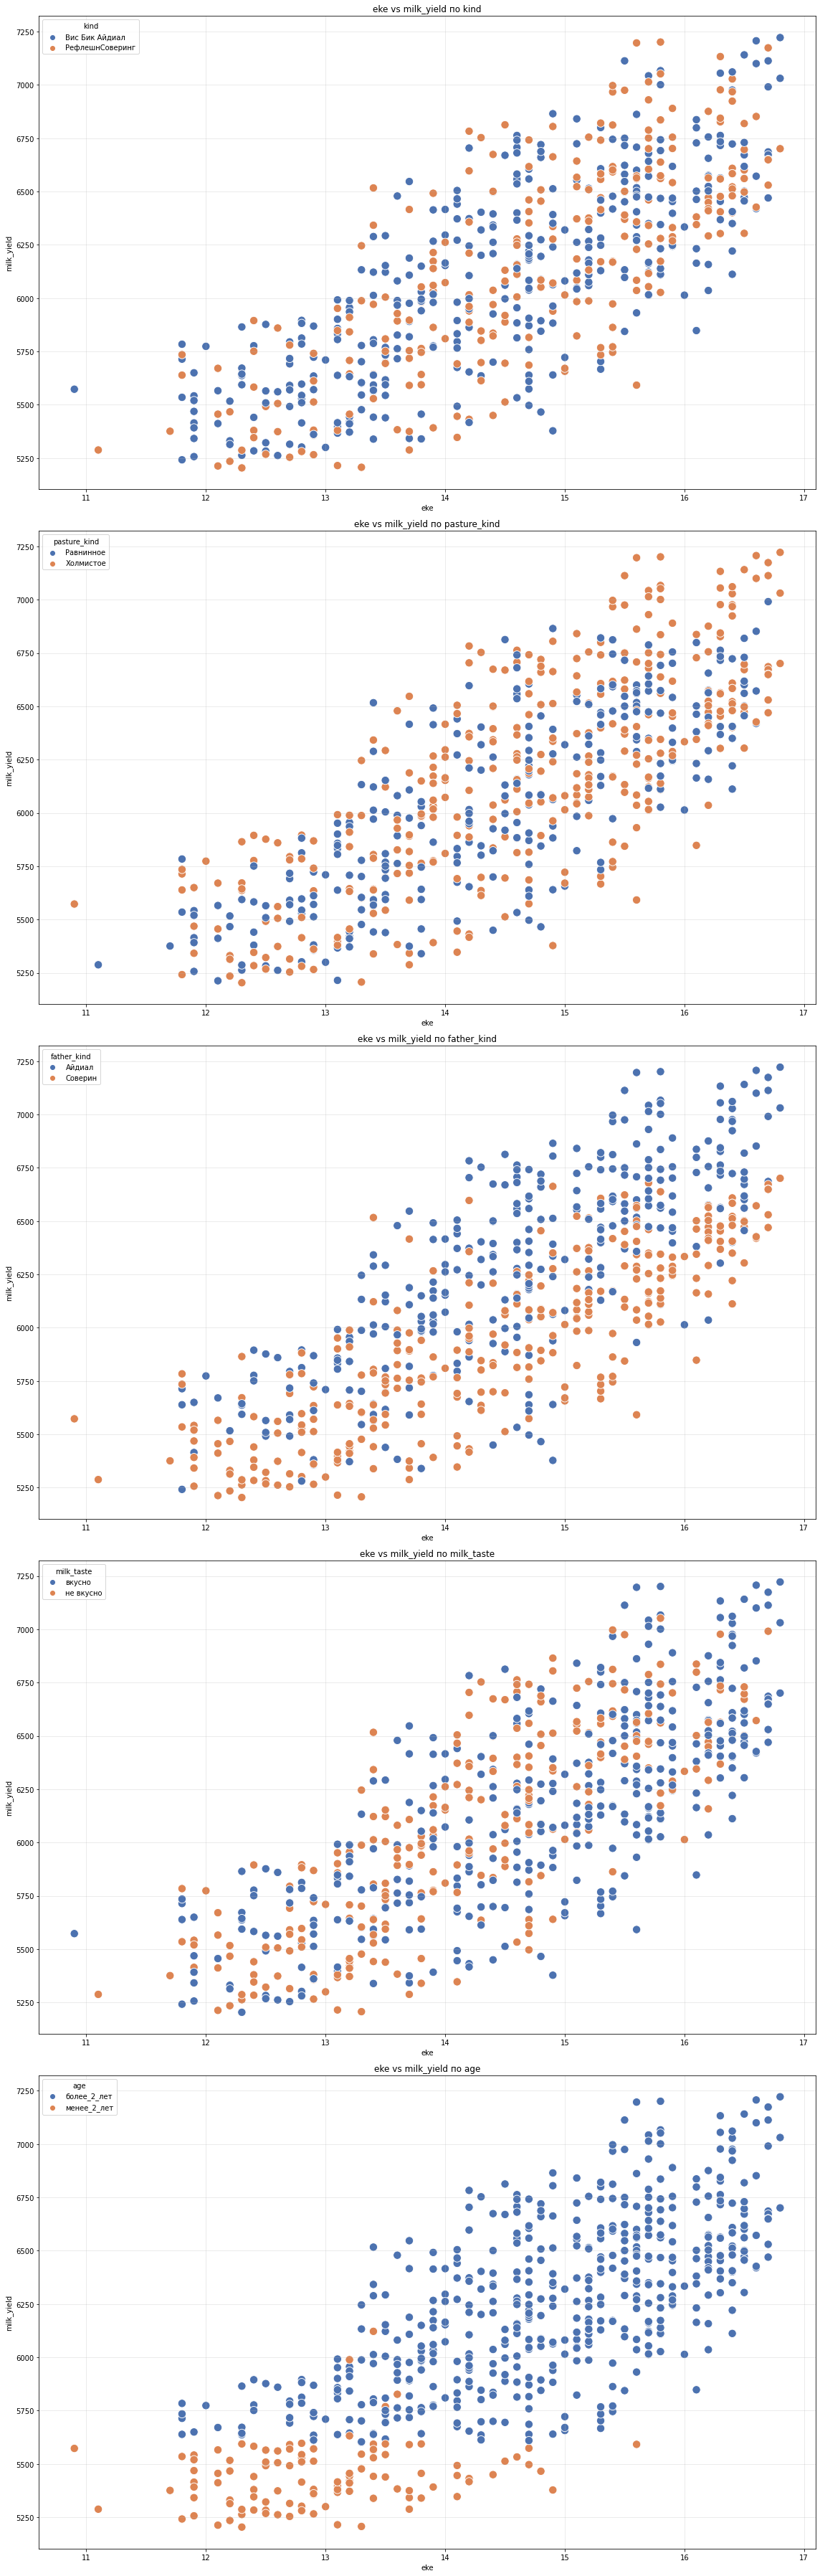

In [71]:
print_scatters(df_ferma_main, 'eke', 'milk_yield')

Между ЭКЕ и удоем наблюдается квадратичная зависимость. Помимо этого:
 - Некоторые коровы на холмистых пастбищах, с высоким ЭКЕ могут давать много молока
 - Коровы породы айдиал показывают хорошие результаты удоя с увеличением ЭКЕ
 - Взрослые коровы дают больше молока

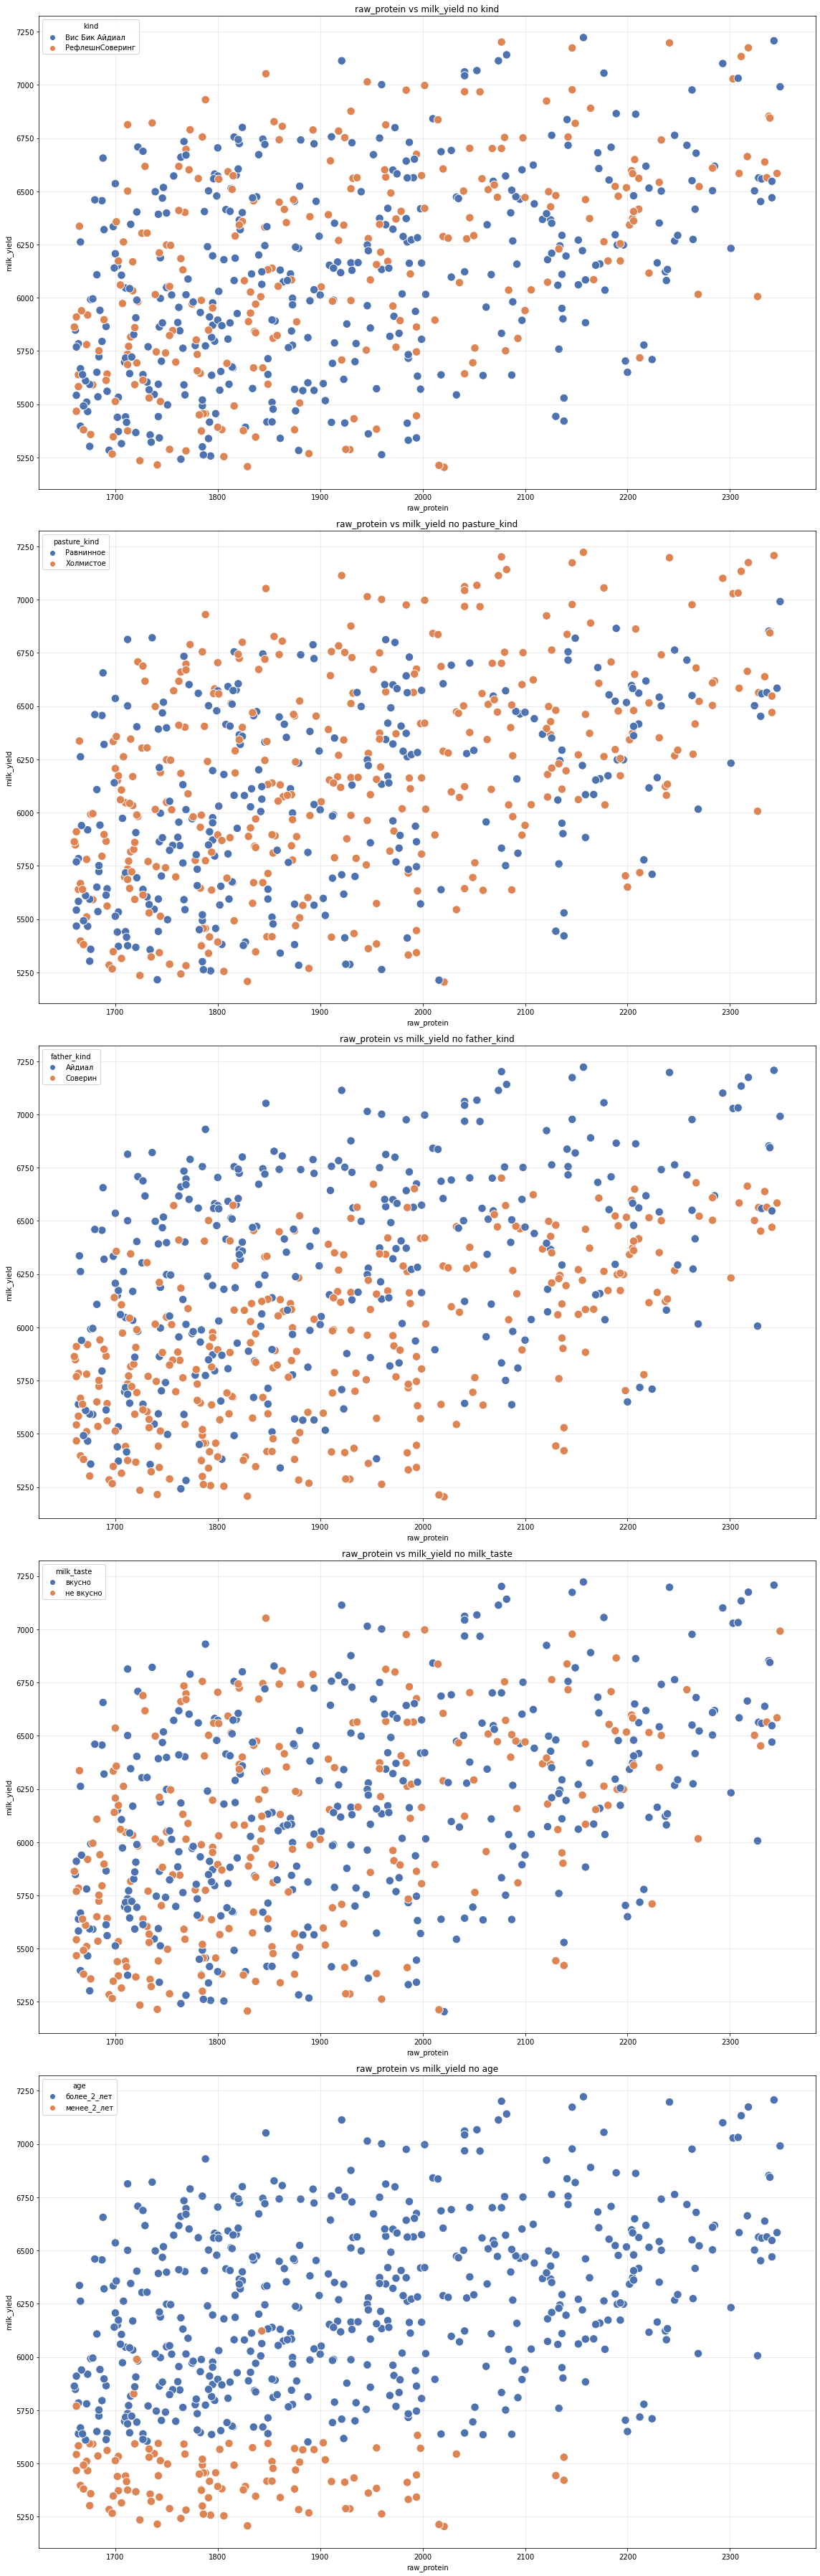

In [72]:
print_scatters(df_ferma_main, 'raw_protein', 'milk_yield')

Между белком в корме и удоем не наблюдается зависиости

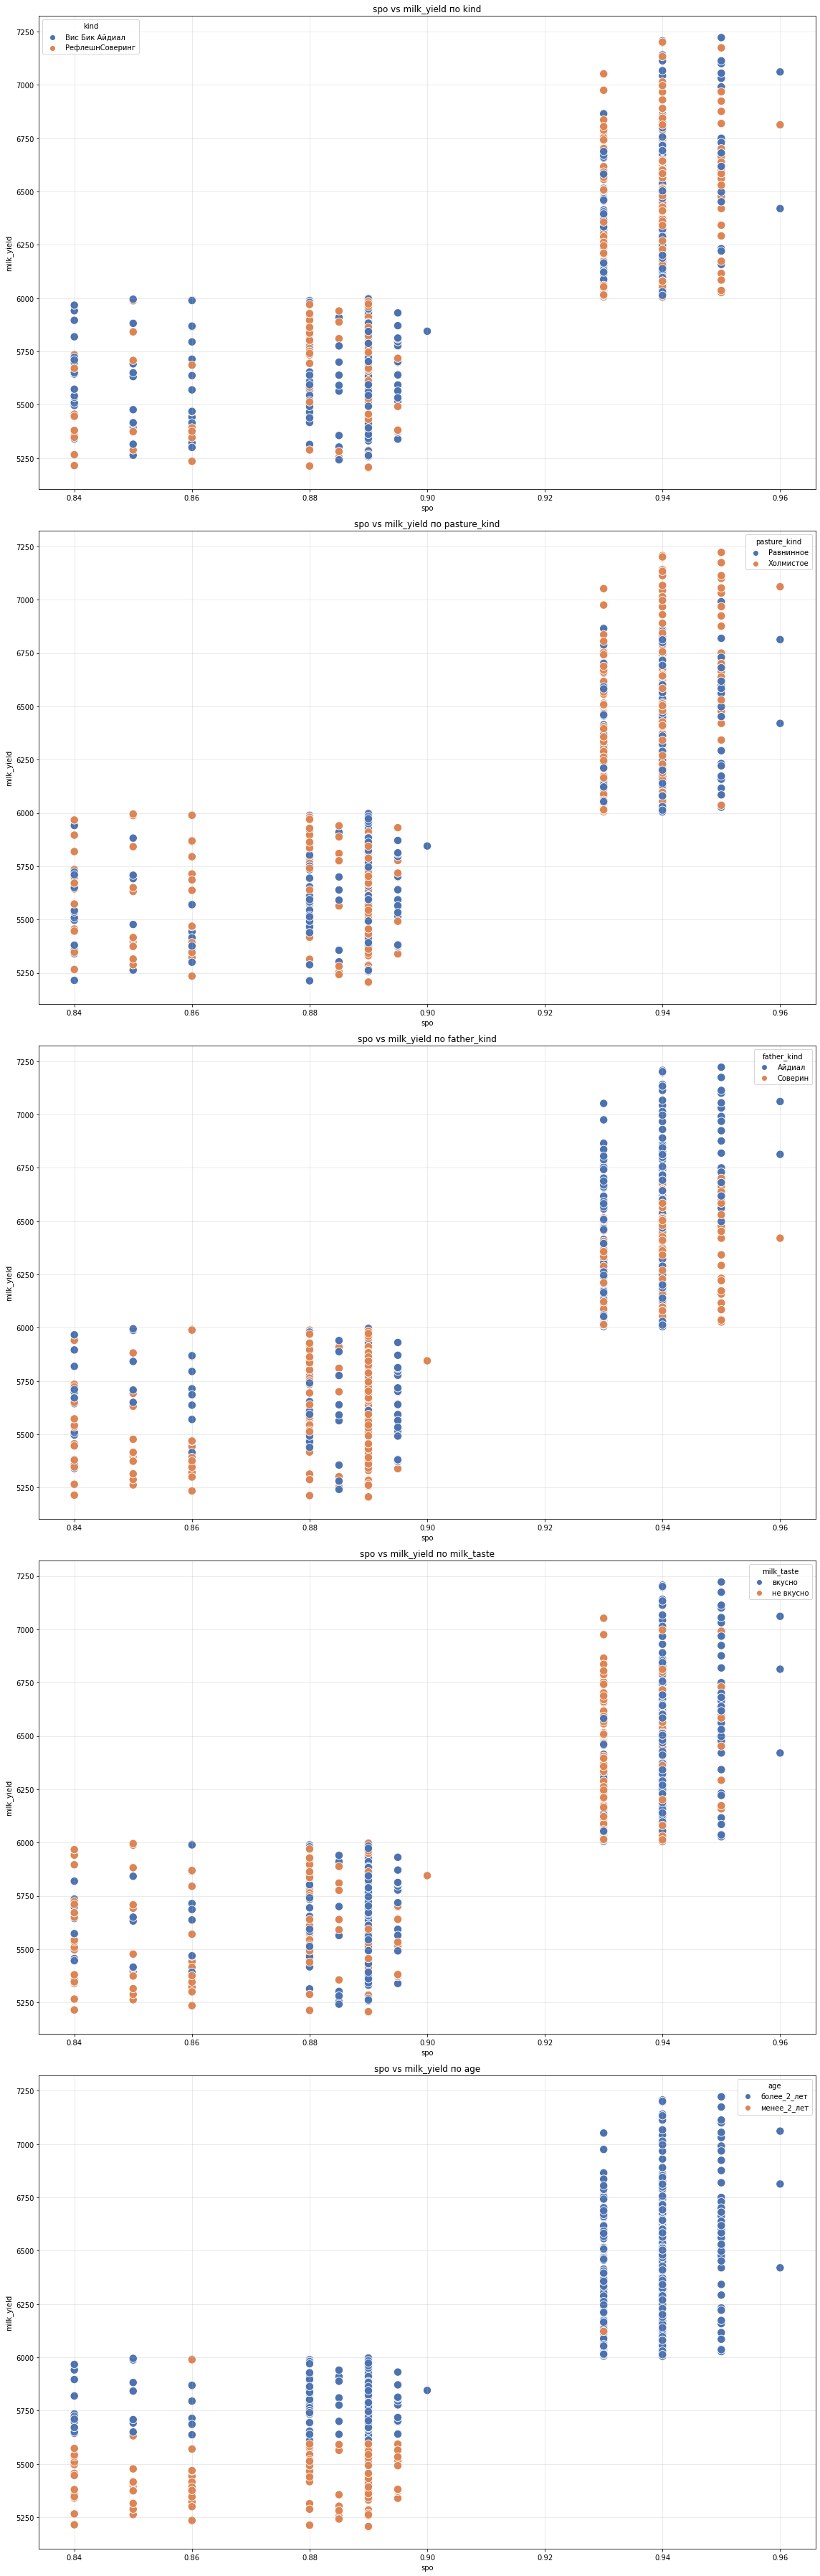

In [73]:
print_scatters(df_ferma_main, 'spo', 'milk_yield')

Коровы с высоким спо дают больше молока

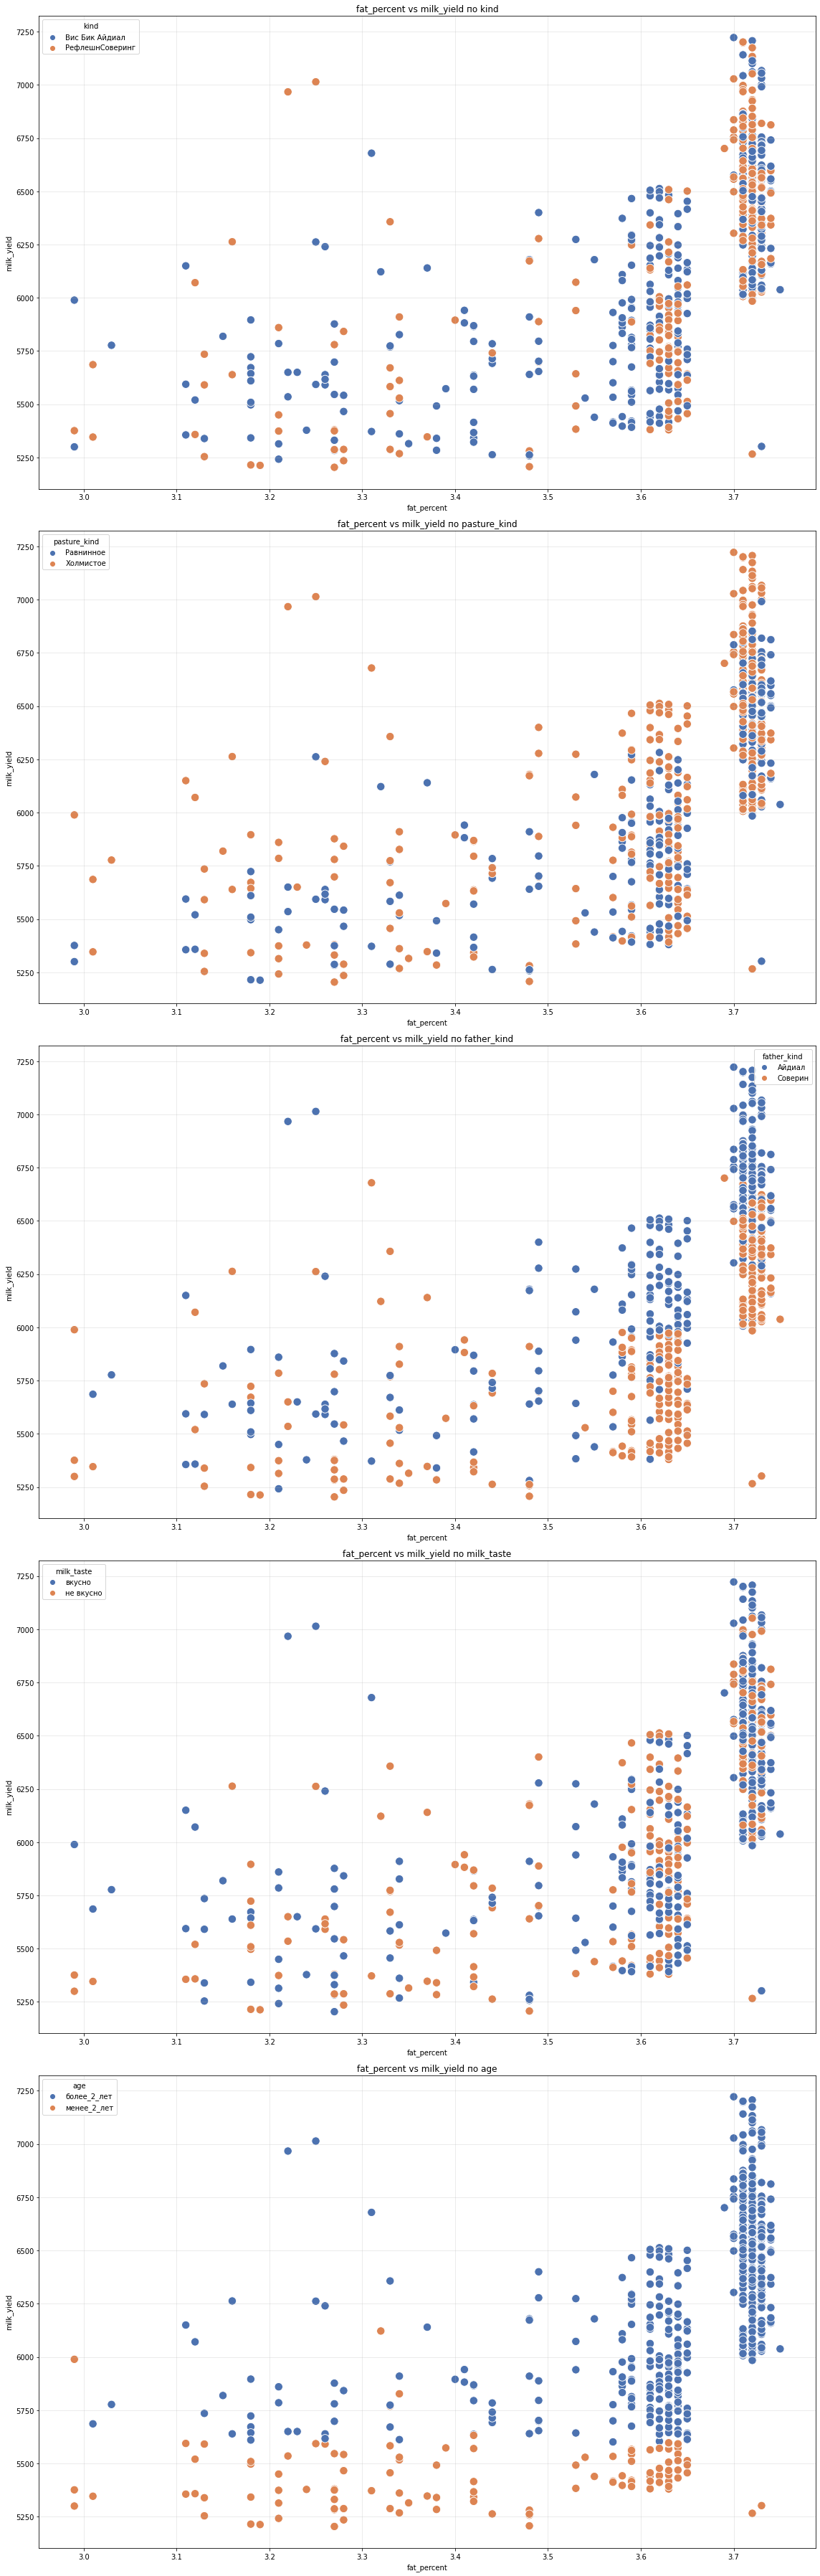

In [74]:
print_scatters(df_ferma_main, 'fat_percent', 'milk_yield')

Между жирностью молока и удоем есть завимиость - у коров с большим удоем молоко жирнее, однако жирность - характеристика молока, а не коровы. Зависимость странная

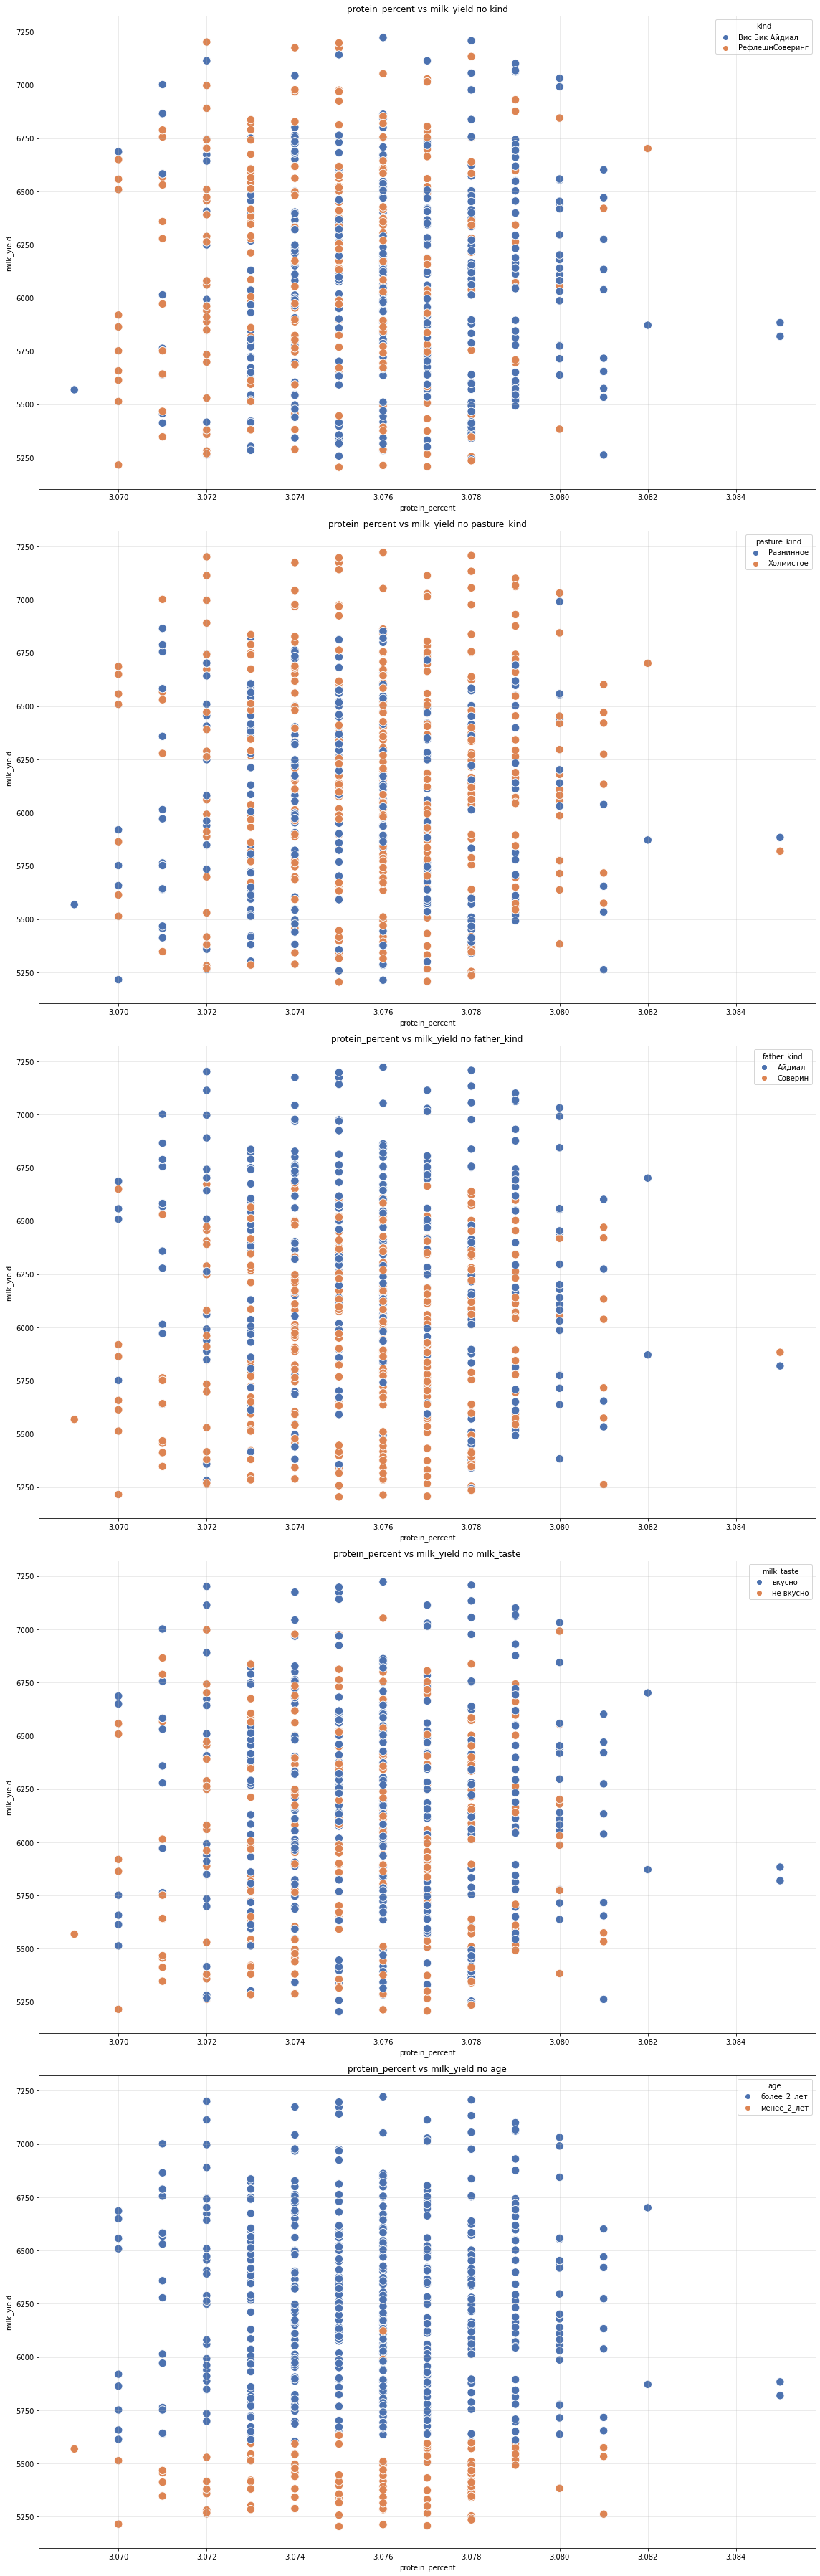

In [75]:
print_scatters(df_ferma_main, 'protein_percent', 'milk_yield')

Между содержанием белка в молоке и удоем нет зависимости

#### Вывод
##### Из корреляционного анализа целевого с целевым можно выявить следующие особенности данных:
 - Между удоем и ЭКЕ обнаружена квадратичная зависимость
 - Некоторые коровы на холмистых пастбищах, с высоким ЭКЕ могут давать много молока
 - Коровы породы айдиал показывают хорошие результаты удоя с увеличением ЭКЕ
 - Взрослые коровы дают больше молока
 - Коровы с высоким спо дают больше молока    
##### Мультиколлинеарность замечена между признаками:
 - Жирность и ЭКЕ
 - Жирность и доля белка
 - Жирность и СПО
 - Возраст и порода папы
 - СПО и сырой протеин
 - Сырой протеин и ЭКЕ
##### Нелинейная связь с целевым признаком замечена среди признаков:
 - ЭКЕ
 - СПО
##### Улучшение данных:
 - ЭКЕ можно возвести в квадрат
 - СПО можно категоризовать

## Обучение модели линейной регрессии

### Обучение 1 модели
Для обучения первой модели по прогнозированию удоя возьмём следующие признаки:
 - ЭКЕ, СПО и содержание белка в корме - эти признаки говорят о том как корову кормят. Корм должен непосредственно влиять на удой
 - Возраст коровы - при корреляционном анализе явно была видна связь с удоем и возрастом, к тому же, большие коровы дают больше молока
 - Порода папы - при корреляционном анализе признак показал связанность с удоем

In [76]:
selected_features = ['eke', 'spo', 'father_kind', 'age', 'raw_protein', 'milk_yield']

df = df_ferma_main[selected_features]
X = df.drop('milk_yield', axis=1)
y = df['milk_yield']
    
cat_col_names = ['father_kind', 'age']
num_col_names = ['eke', 'spo', 'raw_protein']

RANDOM_STATE = 52
X_train, X_test, y_train, y_test_raw = train_test_split(
    X, 
    y, 
    random_state=RANDOM_STATE)
    
encoder = OneHotEncoder(drop='first', sparse_output=False)
X_train_ohe = encoder.fit_transform(X_train[cat_col_names])
X_test_ohe = encoder.transform(X_test[cat_col_names])
    
encoder_col_names = encoder.get_feature_names_out()
   
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_col_names])
X_test_scaled = scaler.transform(X_test[num_col_names])
    
X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)
    
X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)
    
X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)
    
model_lr_raw  = LinearRegression()
model_lr_raw.fit(X_train, y_train)
y_pred_raw = model_lr_raw.predict(X_test)

r2_raw = r2_score(y_test_raw, y_pred_raw)

print(r2_raw)

0.8094188318433106


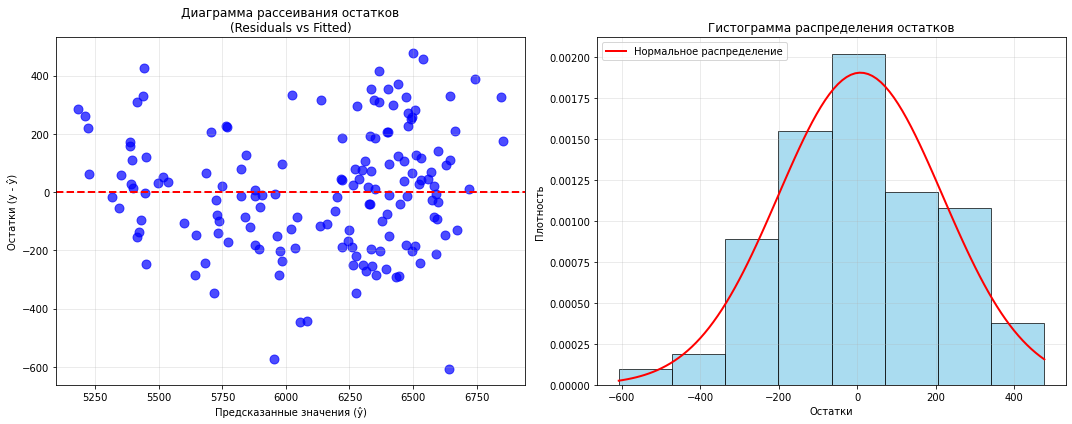

In [77]:
def residuals_analysis(y_test, y_pred):
    residuals = y_test - y_pred
    # Создаем графики
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # 1. Диаграмма рассеивания остатков
    ax1.scatter(pd.Series(y_pred), residuals, alpha=0.7, s=80, color='blue')
    ax1.axhline(y=0, color='red', linestyle='--', linewidth=2)
    ax1.set_xlabel('Предсказанные значения (ŷ)')
    ax1.set_ylabel('Остатки (y - ŷ)')
    ax1.set_title('Диаграмма рассеивания остатков\n(Residuals vs Fitted)')
    ax1.grid(True, alpha=0.3)
    
    # 2. Гистограмма остатков
    ax2.hist(residuals, bins=8, alpha=0.7, color='skyblue', 
             edgecolor='black', density=True)
    ax2.set_xlabel('Остатки')
    ax2.set_ylabel('Плотность')
    ax2.set_title('Гистограмма распределения остатков')
    
    # Добавляем нормальное распределение для сравнения
    from scipy import stats
    x_norm = np.linspace(residuals.min(), residuals.max(), 100)
    y_norm = stats.norm.pdf(x_norm, np.mean(residuals), np.std(residuals))
    ax2.plot(x_norm, y_norm, 'r-', linewidth=2, label='Нормальное распределение')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

residuals_analysis(y_test_raw, y_pred_raw)

#### Выводы после обучения 1 модели
 - R2 метрика показывает 0.8 - это хороший результат
 - Диаграмма рассеивания остатков показывает 2 "кластера". Это плохо т.к. показывает определённую степень неслучайности остатков. Возможно был пропущен важный категориальный признак
 - Диаграмма распределения остатков несмещенна, что говорит о хорошей работе модели

### Обучение 2 модели
Для обучения второй модели возьмём такие же признаки, но категоризуем СПО и возведём ЭКЕ в квадрат

In [78]:
df['spo'] = np.where(df['spo'] < 0.92, 'low', 'high')
df['spo'].value_counts()

/tmp/ipykernel_89/2561607662.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['spo'] = np.where(df['spo'] < 0.92, 'low', 'high')


high    370
low     258
Name: spo, dtype: int64

In [79]:
df['eke'] = df['eke'] ** 2
df['eke'].head()

/tmp/ipykernel_89/2108383630.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['eke'] = df['eke'] ** 2


0    201.64
1    163.84
2    196.00
3    153.76
4    163.84
Name: eke, dtype: float64

In [80]:
X = df.drop('milk_yield', axis=1)
y = df['milk_yield']

cat_col_names = ['father_kind', 'age', 'spo']
num_col_names = ['eke', 'raw_protein']

RANDOM_STATE = 52
X_train, X_test, y_train, y_test_no_square = train_test_split(
    X, 
    y, 
    random_state=RANDOM_STATE)
    
encoder = OneHotEncoder(drop='first', sparse_output=False)
X_train_ohe = encoder.fit_transform(X_train[cat_col_names])
X_test_ohe = encoder.transform(X_test[cat_col_names])
    
encoder_col_names = encoder.get_feature_names_out()
   
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train[num_col_names])
X_test_scaled = scaler.transform(X_test[num_col_names])
    
X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)
    
X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)
    
X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)
    
model_lr_no_square  = LinearRegression()
model_lr_no_square.fit(X_train, y_train)
y_pred_no_square = model_lr_no_square.predict(X_test)

r2_no_square = r2_score(y_test_no_square, y_pred_no_square)

print(r2_no_square)

0.829375677170519


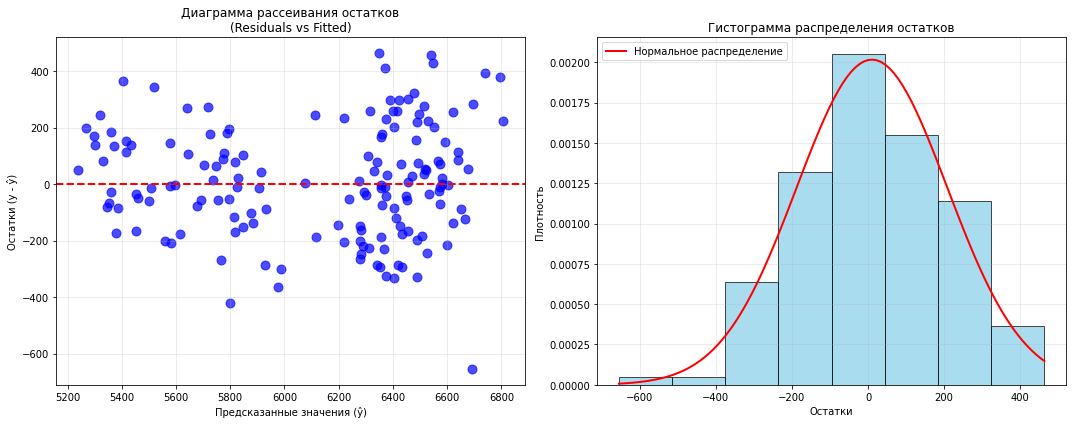

In [81]:
residuals_analysis(y_test_no_square, y_pred_no_square)

#### Выводы после обучения 2 модели
 - R2 метрика показывает 0.829 - это почти на 0.03 больше чем предыдущая модель
 - Диаграмма рассеивания остатков разделилась на 2 чётких кластера, ситуация стала хуже
 - Диаграмма распределения остатков незначительно сместилась влево, анализ остатков показал что модель начала рабоать хуже

### Обучение 3 модели
Для обучения 3 модели возьмём признак из датасета с именами пап коров

In [82]:
df_ferma = pd.merge(df_ferma_main, df_ferma_dad, on='id')
df_ferma.head()

,id,milk_yield,eke,raw_protein,spo,kind,pasture_kind,father_kind,fat_percent,protein_percent,milk_taste,age,father_name
0,1,5863,14.2,1743,0.890,Вис Бик Айдиал,Равнинное,Айдиал,3.58,3.076,вкусно,более_2_лет,Буйный
1,2,5529,12.8,2138,0.890,Вис Бик Айдиал,Равнинное,Соверин,3.54,3.079,вкусно,менее_2_лет,Соловчик
2,3,5810,14.0,1854,0.885,РефлешнСоверинг,Холмистое,Соверин,3.59,3.074,не вкусно,более_2_лет,Барин
3,4,5895,12.4,2012,0.885,РефлешнСоверинг,Холмистое,Айдиал,3.40,3.075,не вкусно,более_2_лет,Буйный
4,5,5302,12.8,1675,0.885,Вис Бик Айдиал,Равнинное,Соверин,3.73,3.073,вкусно,менее_2_лет,Барин


In [83]:
df_ferma.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 628 entries, 0 to 627
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               628 non-null    int64  
 1   milk_yield       628 non-null    int64  
 2   eke              628 non-null    float64
 3   raw_protein      628 non-null    int64  
 4   spo              628 non-null    float64
 5   kind             628 non-null    object 
 6   pasture_kind     628 non-null    object 
 7   father_kind      628 non-null    object 
 8   fat_percent      628 non-null    float64
 9   protein_percent  628 non-null    float64
 10  milk_taste       628 non-null    object 
 11  age              628 non-null    object 
 12  father_name      628 non-null    object 
dtypes: float64(4), int64(3), object(6)
memory usage: 68.7+ KB


In [84]:
selected_features = ['eke', 'spo', 'father_kind', 'age', 'father_name', 'raw_protein', 'milk_yield']

df = df_ferma[selected_features]
df['spo'] = np.where(df['spo'] < 0.92, 'low', 'high')
df['eke'] = df['eke'] ** 2

X = df.drop('milk_yield', axis=1)
y = df['milk_yield']
    
cat_col_names = ['father_kind', 'age', 'spo', 'father_name']
num_col_names = ['eke', 'raw_protein']

RANDOM_STATE = 52
X_train, X_test, y_train, y_test_fine = train_test_split(
    X, 
    y, 
    random_state=RANDOM_STATE)
    
encoder_fine = OneHotEncoder(drop='first', sparse_output=False)
X_train_ohe = encoder_fine.fit_transform(X_train[cat_col_names])
X_test_ohe = encoder_fine.transform(X_test[cat_col_names])
    
encoder_col_names = encoder_fine.get_feature_names_out()
   
scaler_fine = StandardScaler()
X_train_scaled = scaler_fine.fit_transform(X_train[num_col_names])
X_test_scaled = scaler_fine.transform(X_test[num_col_names])
    
X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)
    
X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)
    
X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)
    
model_lr_fine  = LinearRegression()
model_lr_fine.fit(X_train, y_train)
y_pred_fine = model_lr_fine.predict(X_test)

r2_fine = r2_score(y_test_fine, y_pred_fine)

print(r2_fine)

0.8424538288372112


/tmp/ipykernel_89/1072623037.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['spo'] = np.where(df['spo'] < 0.92, 'low', 'high')
/tmp/ipykernel_89/1072623037.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['eke'] = df['eke'] ** 2


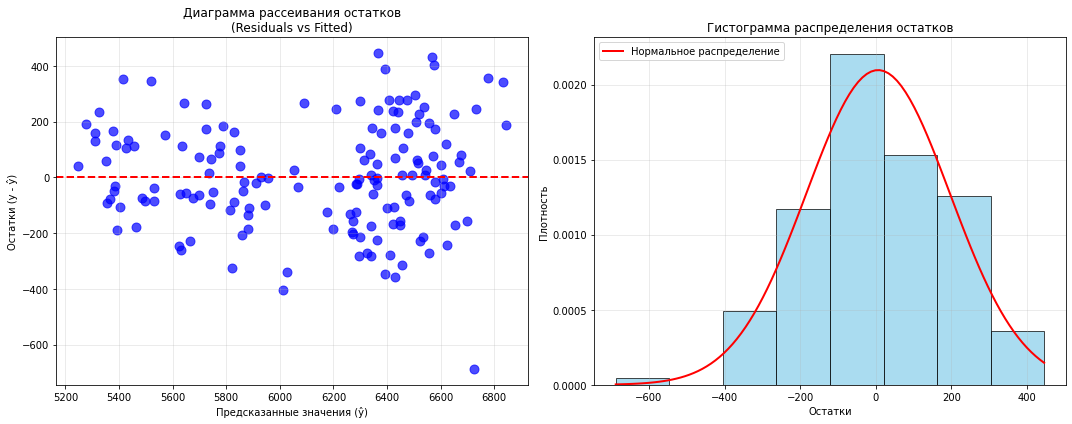

In [85]:
residuals_analysis(y_test_fine, y_pred_fine)

### Выводы обучения 3 модели:
 - R2 метрика показывает 0.842 - самый высокий результат среди всех 3 моделей
 - Диаграмма рассеивания остатков окончательно разделилась на 2 кластера
 - Диаграмма распределения остатков сместилась ещё дальше

## Итоговые выводы обучение модели линейной регрессии

Рассмотрим R2 метрики всех 3 моделей

In [86]:
print(f"""
R2 первой модели: {r2_raw}
R2 модели с исправленной нелинейностью: {r2_no_square}
R2 финальной модели с новым признаком: {r2_fine}
""")


R2 первой модели: 0.8094188318433106
R2 модели с исправленной нелинейностью: 0.829375677170519
R2 финальной модели с новым признаком: 0.8424538288372112



Последняя итерация показала самый лучший результат по метрике R2

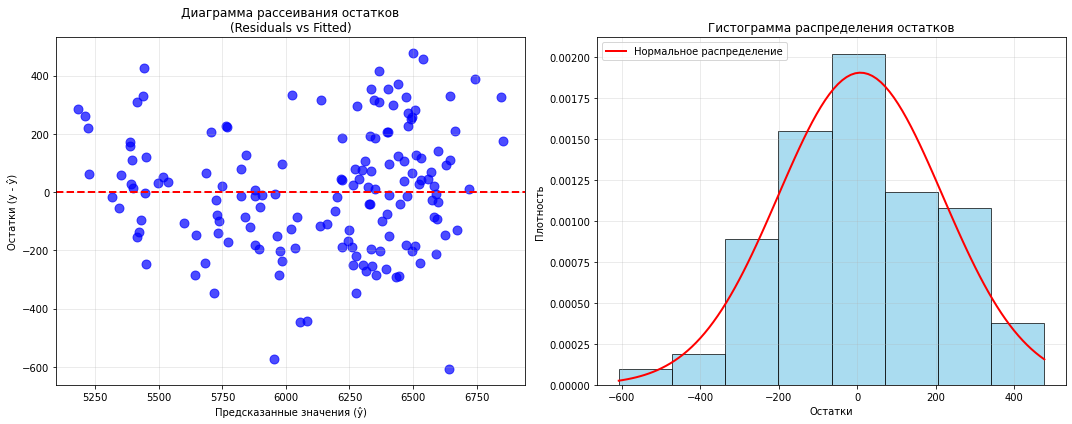

In [87]:
residuals_analysis(y_test_raw, y_pred_raw)

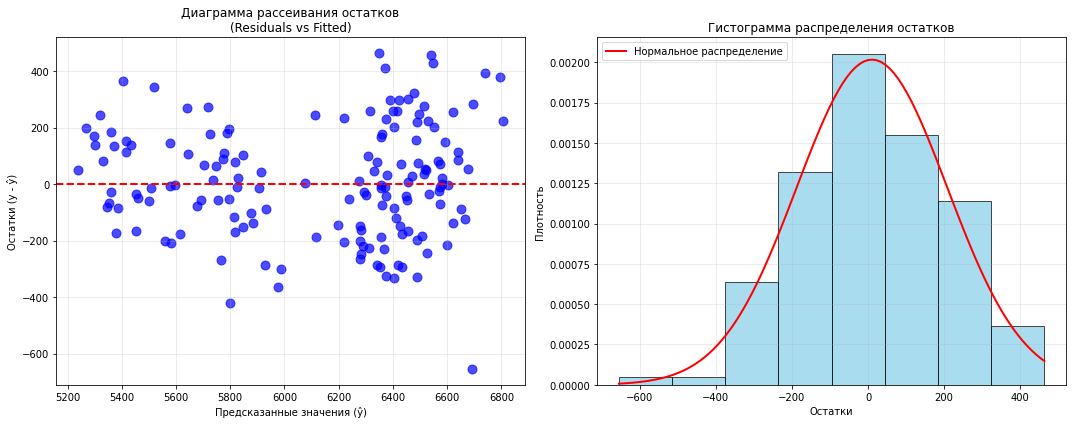

In [88]:
residuals_analysis(y_test_no_square, y_pred_no_square)

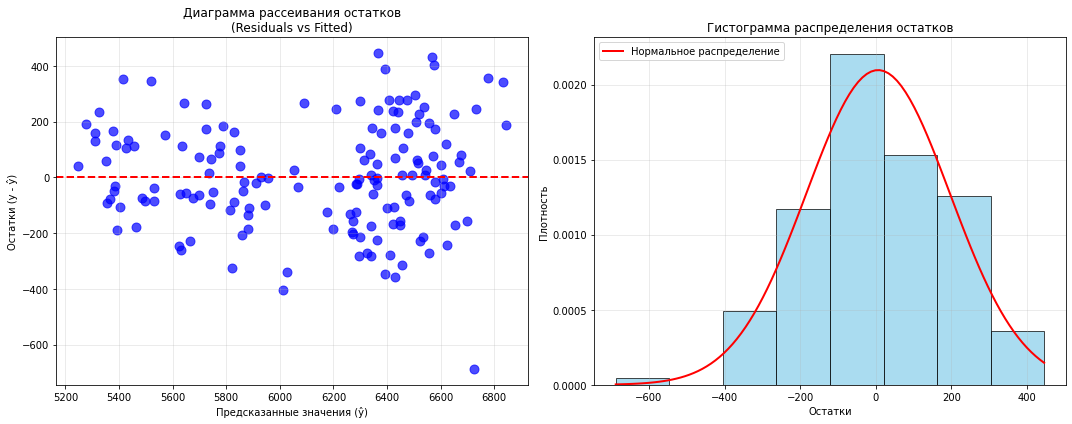

In [89]:
residuals_analysis(y_test_fine, y_pred_fine)

По анализу остатков лучше всего справилась 1 модель, демонстрируя максимальную случайность остатков и максимальное приближение к нормальному распределению

In [90]:
# Функции для расчета метрик
def calculate_mse(y_true, y_pred):
    """Вычисляет Mean Squared Error (MSE)"""
    return mean_squared_error(y_true, y_pred)

def calculate_mae(y_true, y_pred):
    """Вычисляет Mean Absolute Error (MAE)"""
    return mean_absolute_error(y_true, y_pred)

def calculate_rmse(y_true, y_pred):
    """Вычисляет Root Mean Squared Error (RMSE)"""
    return np.sqrt(mean_squared_error(y_true, y_pred))

def evaluate_model(y_true, y_pred, model_name):
    """Вычисляет все три метрики для модели"""
    mse = calculate_mse(y_true, y_pred)
    mae = calculate_mae(y_true, y_pred)
    rmse = calculate_rmse(y_true, y_pred)
    
    return {
        'Model': model_name,
        'MSE': mse,
        'MAE': mae,
        'RMSE': rmse
    }

In [91]:
# Оцениваем каждую модель
models_metrics = []
    
models_metrics.append(evaluate_model(y_test_raw, y_pred_raw, "Сырая модель"))
models_metrics.append(evaluate_model(y_test_no_square, y_pred_no_square, "Модель с исправленной нелинейностью"))
models_metrics.append(evaluate_model(y_test_fine, y_pred_fine, "Модель с доп признаком"))
    
# Создаем датафрейм
results_df = pd.DataFrame(models_metrics)
results_df

,Model,MSE,MAE,RMSE
0,Сырая модель,43848.436787,167.529346,209.400183
1,Модель с исправленной нелинейностью,39256.815909,158.813503,198.133329
2,Модель с доп признаком,36247.827601,151.813912,190.388623


Последняя модель показала наилучшие показатели по всем трём метрикам. Для моделирования будем использовать именно её

Произведём подготовку данных "ЭкоФермы" для прогнозирования

In [92]:
df_cow_buy.head()

,kind,pasture_kind,father_kind,father_name,fat_percent,protein_percent,age
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет


In [93]:
df_cow_buy_prepared = df_cow_buy.copy()
df_cow_buy_prepared['eke'] = df_ferma_main['eke'].mean() * 1.05
df_cow_buy_prepared['spo'] = df_ferma_main['spo'].mean() * 1.05
df_cow_buy_prepared['raw_protein'] = df_ferma_main['raw_protein'].mean() * 1.05

df_cow_buy_prepared.head()

,kind,pasture_kind,father_kind,father_name,fat_percent,protein_percent,age,eke,spo,raw_protein
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,15.276162,0.958744,2019.947532
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет,15.276162,0.958744,2019.947532
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет,15.276162,0.958744,2019.947532
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет,15.276162,0.958744,2019.947532
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет,15.276162,0.958744,2019.947532


Данные готовы, используем готовую модель

In [94]:
selected_features = ['eke', 'spo', 'father_kind', 'age', 'father_name', 'raw_protein']

df = df_cow_buy_prepared[selected_features]
df['spo'] = np.where(df['spo'] < 0.92, 'low', 'high')
df['eke'] = df['eke'] ** 2
    
cat_col_names = ['father_kind', 'age', 'spo', 'father_name']
num_col_names = ['eke', 'raw_protein']

df_prod_ohe = encoder_fine.transform(df[cat_col_names])
    
encoder_col_names = encoder_fine.get_feature_names_out()
   
df_prod_scaled = scaler_fine.transform(df[num_col_names])
    
df_prod_ohe = pd.DataFrame(df_prod_ohe, columns=encoder_col_names)
    
df_prod_scaled = pd.DataFrame(df_prod_scaled, columns=num_col_names)
    
df_prod = pd.concat([df_prod_ohe, df_prod_scaled], axis=1)

y_yield_pred_prod = model_lr_fine.predict(df_prod)

pred_yield = pd.Series(y_yield_pred_prod)
pred_yield.describe()

/tmp/ipykernel_89/943982343.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['spo'] = np.where(df['spo'] < 0.92, 'low', 'high')
/tmp/ipykernel_89/943982343.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['eke'] = df['eke'] ** 2


count      16.000000
mean     6428.434189
std       141.383620
min      6102.248383
25%      6331.797634
50%      6444.588511
75%      6555.404008
max      6559.255302
dtype: float64

Все коровы "ЭкоФермы" подходят для заказчика. Это может быть связано с заранее завышенными показателями входных признаков

## Обучение модели логистической регрессии

Обучим модель логистической регрессии

In [95]:
df = df_ferma.copy()
df['milk_taste'] = df['milk_taste'].apply(lambda x: 1 if x == 'вкусно' else 0)
df = df.drop('milk_yield', axis=1)
X = df.drop('milk_taste', axis=1)
y = df['milk_taste']
    
cat_col_names = ['father_kind', 'kind', 'pasture_kind', 'age', 'father_name']
num_col_names = ['eke', 'raw_protein', 'spo', 'fat_percent', 'protein_percent']

RANDOM_STATE = 52
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    random_state=RANDOM_STATE)
    
encoder_clf = OneHotEncoder(drop='first', sparse_output=False)
X_train_ohe = encoder_clf.fit_transform(X_train[cat_col_names])
X_test_ohe = encoder_clf.transform(X_test[cat_col_names])
    
encoder_col_names = encoder_clf.get_feature_names_out()
   
scaler_clf = StandardScaler()
X_train_scaled = scaler_clf.fit_transform(X_train[num_col_names])
X_test_scaled = scaler_clf.transform(X_test[num_col_names])
    
X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)
    
X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_col_names)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_col_names)
    
X_train = pd.concat([X_train_ohe, X_train_scaled], axis=1)
X_test = pd.concat([X_test_ohe, X_test_scaled], axis=1)
    
clf  = LogisticRegression()
clf = clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)

print('accuracy: ', round(accuracy, 3))
print('recall: ',round(recall ,3))
print('precision: ',round(precision,3))

accuracy:  0.58
recall:  0.775
precision:  0.6


Модель обучена, значения метрик:
 - accuracy:  0.58
 - recall:  0.775
 - precision:  0.6

Построим confusion matrix

Confusion Matrix:
[[22 46]
 [20 69]]


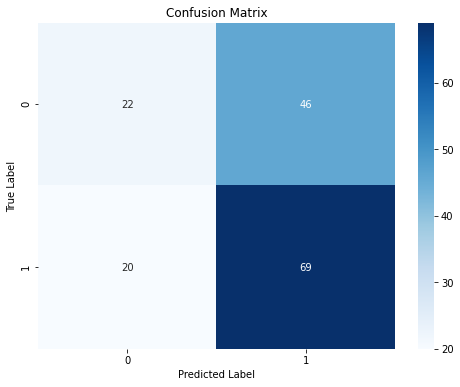

In [96]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Визуализация
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Для заказчика больше всего важна метрика precision. Очевидно что в интересах заказчика получить коров только с вкусным молоком. Мы не можем допустить ошибку, когда мы относим молоко к вкусному, а на самом деле оно не вкусное. Так заказчик потратит лишние деньги. Для правильной работы необходимо свести ошибку первого рода к нулю. Для этого, необходимо повысить порог классификации

Confusion Matrix:
[[68  0]
 [84  5]]


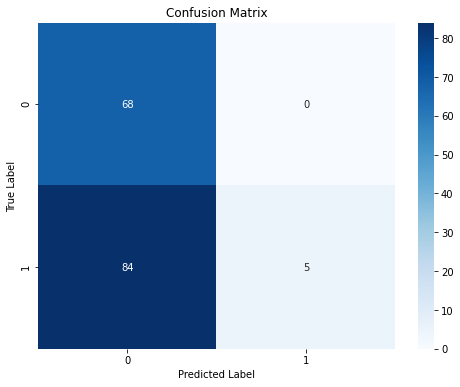

In [97]:
# Получаем вероятности для положительного класса
y_pred_proba = clf.predict_proba(X_test)[:, 1]  # вероятности класса 1

# Повышаем порог с 0.5 до 0.7
threshold = 0.852
y_pred_high_threshold = (y_pred_proba >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_high_threshold)
print("Confusion Matrix:")
print(cm)

# Визуализация
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [98]:
accuracy = accuracy_score(y_test, y_pred_high_threshold)
recall = recall_score(y_test, y_pred_high_threshold)
precision = precision_score(y_test, y_pred_high_threshold)

print('accuracy: ', round(accuracy, 3))
print('recall: ',round(recall ,3))
print('precision: ',round(precision,3))

accuracy:  0.465
recall:  0.056
precision:  1.0


Порог классификации был повышен, метрика precision теперь равна 1, то есть на тестовой выборке мы не предсказали хороший вкус молока, хотя на самом деле вкус у него плохой. Переходим к предсказанию на валидационной выборке

Предобработаем данные как для обучения, произведём моделирование

In [99]:
df_cow_buy_prepared = df_cow_buy.copy()
df_cow_buy_prepared['eke'] = df_ferma_main['eke'].mean() * 1.05
df_cow_buy_prepared['spo'] = df_ferma_main['spo'].mean() * 1.05
df_cow_buy_prepared['raw_protein'] = df_ferma_main['raw_protein'].mean() * 1.05

df_cow_buy_prepared.head()

,kind,pasture_kind,father_kind,father_name,fat_percent,protein_percent,age,eke,spo,raw_protein
0,Вис Бик Айдиал,холмистое,Айдиал,Геркулес,3.58,3.076,более_2_лет,15.276162,0.958744,2019.947532
1,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.54,3.081,менее_2_лет,15.276162,0.958744,2019.947532
2,РефлешнСоверинг,равнинное,Соверин,Барин,3.59,3.074,более_2_лет,15.276162,0.958744,2019.947532
3,РефлешнСоверинг,холмистое,Айдиал,Буйный,3.40,3.061,более_2_лет,15.276162,0.958744,2019.947532
4,РефлешнСоверинг,равнинное,Айдиал,Буйный,3.64,3.074,более_2_лет,15.276162,0.958744,2019.947532


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 628 entries, 0 to 627
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               628 non-null    int64  
 1   eke              628 non-null    float64
 2   raw_protein      628 non-null    int64  
 3   spo              628 non-null    float64
 4   kind             628 non-null    object 
 5   pasture_kind     628 non-null    object 
 6   father_kind      628 non-null    object 
 7   fat_percent      628 non-null    float64
 8   protein_percent  628 non-null    float64
 9   milk_taste       628 non-null    int64  
 10  age              628 non-null    object 
 11  father_name      628 non-null    object 
dtypes: float64(4), int64(3), object(5)
memory usage: 63.8+ KB


In [101]:
df = df_cow_buy_prepared.copy()

df ['pasture_kind'] = df['pasture_kind'].apply(lambda x: 'Холмистое' if x == 'холмистое' else 'Равнинное')

cat_col_names = ['father_kind', 'kind', 'pasture_kind', 'age', 'father_name']
num_col_names = ['eke', 'raw_protein', 'spo', 'fat_percent', 'protein_percent']

X_ohe = encoder_clf.transform(df[cat_col_names])
    
encoder_col_names = encoder_clf.get_feature_names_out()
   
X_scaled = scaler_clf.transform(df[num_col_names])

X_ohe = pd.DataFrame(X_ohe, columns=encoder_col_names)
    
X_scaled = pd.DataFrame(X_scaled, columns=num_col_names)
    
X = pd.concat([X_ohe, X_scaled], axis=1)

In [102]:
y_pred_proba = clf.predict_proba(X)[:, 1]  # вероятности класса 1

threshold = 0.852
y_pred_taste_high_threshold = (y_pred_proba >= threshold).astype(int)

pred_taste = pd.Series(y_pred_taste_high_threshold)
pred_taste.value_counts()

0    14
1     2
dtype: int64

Из всех 16 коров, подходят только 2

## Итоговые выводы

Добавим прогнозируемые значения в датасет "ЭкоФермы"

In [103]:
df_cow_buy['milk_taste'] = pred_taste
df_cow_buy['milk_yield'] = pred_yield

Отберём коров по требованиям:
 - Удой больше 6000 литров
 - Молоко должно быть вкусным

In [104]:
df_cow_buy.query('milk_taste == 1 & milk_yield > 6000')

,kind,pasture_kind,father_kind,father_name,fat_percent,protein_percent,age,milk_taste,milk_yield
7,Вис Бик Айдиал,равнинное,Соверин,Буйный,3.57,3.079,более_2_лет,1.0,6340.607788
11,РефлешнСоверинг,равнинное,Соверин,Геркулес,3.73,3.073,более_2_лет,1.0,6102.248383


Заказчик может с минимальным риском купить себе двух коров из представленного каталога "Экофермы". На этапе обучения модели, порог классификации был "завышен", для того чтобы отобрать коров с вкусным молоком, с минимальной вероятностью ошибки 1 рода (корове с невкусным молоком будет спрогнозировано вкусное молоко)

Помимо этого, заказчику можно дать следующую рекомендацию:
 - Взрослые коровы породы Айдиал с высоким СПО и ЭКЕ дают много молока

Выводы о моделях линейной регрессии и логистической регрессии:
 - В ходе работы для улучшения модели линейной регрессии:
   - Были отобраны признаки, которую имеют логичную связь с целевым
   - Добавлен новый признак из другого набора данных
   - Обеспечена линейная зависимость для признаков
 - Модель линейной регрессии можно улучшить следующим образом:
   - Добавить новые признаки в изначальные данные
   - Добавить больше данных для обучения
 - Метрики, которые важны при анализе рисков или экономических расчётов:
   - Precision - Высокая точность означает, что когда мы предсказываем риск, мы почти всегда правы. Это критически важно, когда стоимость FP (ложной тревоги) высока.
   - Recall - Способность обнаруживать угрозы. Высокая полнота означает, что мы пропускаем очень мало реальных рисков. Это критически важно, когда стоимость FN (пропущенной угрозы) катастрофически высока.